In [2]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [3]:
from stericheight.data_handler import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [4]:
import gsw
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import root_scalar


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'
fname_spira=fname = '../data/qc_profile_ds_2dbar.nc'

In [5]:
sla = SLA(deg=0.25).da
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
elevation_ = GEBCO(coarsen_factor=40).ds.elevation
ds = xr.open_dataset(fname).swap_dims({'n_prof':'time'})


In [6]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

In [7]:
extent =[100,160,-69,-65.2]
extent_mertz =[138.5,143,-67,-65.6]
extent_vcbay = [106,114,-70,-65.2]
extent_voyeykov = [121,128,-70,-65.4]
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


In [8]:
# set up lines of constant density

tlims = [-2.1,0.4]
slims = [32.9,34.9]
sig0_n = 100
temprange = np.linspace(tlims[0],tlims[1],sig0_n)
psalrange = np.linspace(slims[0],slims[1],sig0_n)

sig0range = np.zeros((sig0_n,sig0_n))
for i,t in enumerate(temprange):
    for j,s in enumerate(psalrange):
        sig0range[i,j]=gsw.sigma0(s,gsw.CT_from_t(s,t,0))


In [9]:
shelf = Region('EA Shelf',extent,elevation_,min_elevation=-1000)
voyeykov = Region('Voyeykov',extent_voyeykov)
mertz = Region('Mertz',extent_mertz)
vcbay = Region('Vincennes Bay',extent_vcbay)
# fig, ax = plt.subplots(1,3,figsize=(10,3),subplot_kw={'projection':ccrs.SouthPolarStereo()})
# voyeykov.plot_region(ax=ax[0],extent=extent)
# mertz.plot_region(ax=ax[1],extent=extent)
# vcbay.plot_region(ax=ax[2],extent=extent)

In [9]:
meop_mertz=MEOP(extent=extent_mertz)
meop_mertz.load_profiles()

100%|██████████| 81/81 [03:11<00:00,  2.37s/it]


,platform,latitude,longitude,filename,temperature,salinity,gph,nlevels
time,,,,,,,,
2007-02-20 15:19:59,wd3-CTD2-07,-66.6190,139.9200,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.149898,10
2007-02-20 23:29:59,wd3-CTD2-07,-66.5560,140.0420,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.161139,19
2007-02-21 04:40:00,wd3-CTD2-07,-66.5868,140.0270,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.129097,10
2007-02-21 08:39:58,wd3-CTD2-07,-66.5839,139.9780,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.171173,19
2007-02-21 17:29:59,wd3-CTD2-07,-66.6441,140.0330,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.154512,10
...,...,...,...,...,...,...,...,...
2019-06-08 07:49:59,wd11-768-18,-66.6608,141.3027,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.013696,36
2019-06-08 23:09:59,wd11-768-18,-66.6508,141.3139,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.027960,16
2019-06-09 15:50:00,wd11-768-18,-66.6525,141.3284,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.028732,16


In [10]:
sla_shelf = shelf.crop_da(sla)

# also do spira data
spira_mertz = ds.where(
    (ds.lon > extent[0]) &
    (ds.lon < extent[1]) &
    (ds.lat > extent[2]) &
    (ds.lat < extent[3]), drop=True
)

In [11]:
background_data = sanom(mertz.crop_da(sla)).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
#cmp.add_meop(meop_mertz,tlims=tlims,slims=slims)
cmp.add_spira(spira_mertz,tlims=tlims,slims=slims)

In [12]:
cmp.build_sns_data()

preparing data


<Axes: xlabel='month', ylabel='count'>

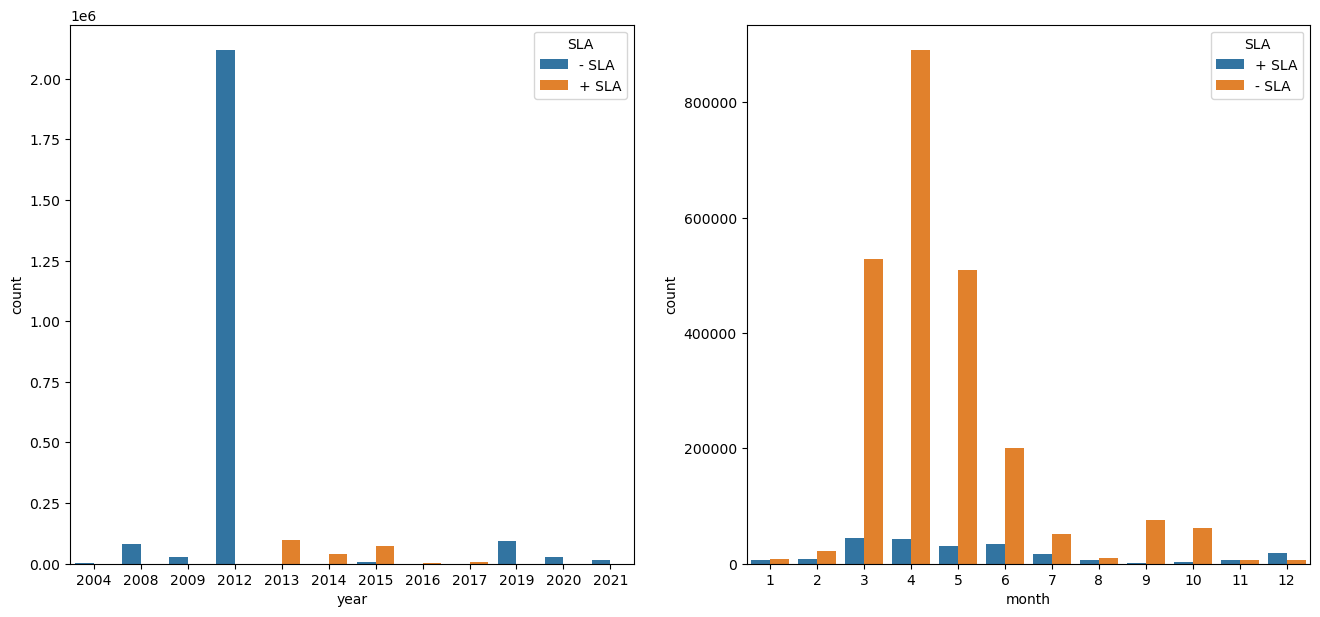

In [14]:
fig, ax = plt.subplots(1,2,figsize=(16,7))
sns.countplot(cmp.sns_data, x='year', hue='SLA',ax=ax[0])
sns.countplot(cmp.sns_data, x='month', hue='SLA',ax=ax[1])

In [ ]:
sns.kdeplot(data=cmp.sns_data,x='sigma0',y='pressure')

In [ ]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax2,ax3],sanom(shelf.crop_da(sla)),'SLA',12,extent,label_loc=[130,-80])

# FIG3: SLA closeup
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax4,ax5],sanom(shelf.crop_da(sla)),'SLA',12,extent_mertz,add_profiles=True)

n = 5
cmp.ts_freq_plot([ 
    fig.add_subplot(gs[n,0]),
    fig.add_subplot(gs[n,1]),
    fig.add_subplot(gs[n,2]),
    fig.add_subplot(gs[n,3]),
])

# FIG4: TS DESNITY
n = 6
cmp.ts_density([
    fig.add_subplot(gs[n:n+2,0:2]),
    fig.add_subplot(gs[n:n+2,2:4])
    ])

ax6 = fig.add_subplot(gs[n:n+2,0:2])
ax7 = fig.add_subplot(gs[n:n+2,2:4])


# FIG5: TS PROFILES
n = 8
ax8 = fig.add_subplot(gs[8:10,0])
ax9 = fig.add_subplot(gs[8:10,1])
ax10 = fig.add_subplot(gs[8:10,2])
ax11 = fig.add_subplot(gs[8:10,3])
cmp.ts_profiles([ax8,ax9,ax10,ax11])

plt.tight_layout()



In [16]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims,lag=6)

reindexing temps..
reindexing psals...
merging...
reindexing temps..
reindexing psals...
merging...


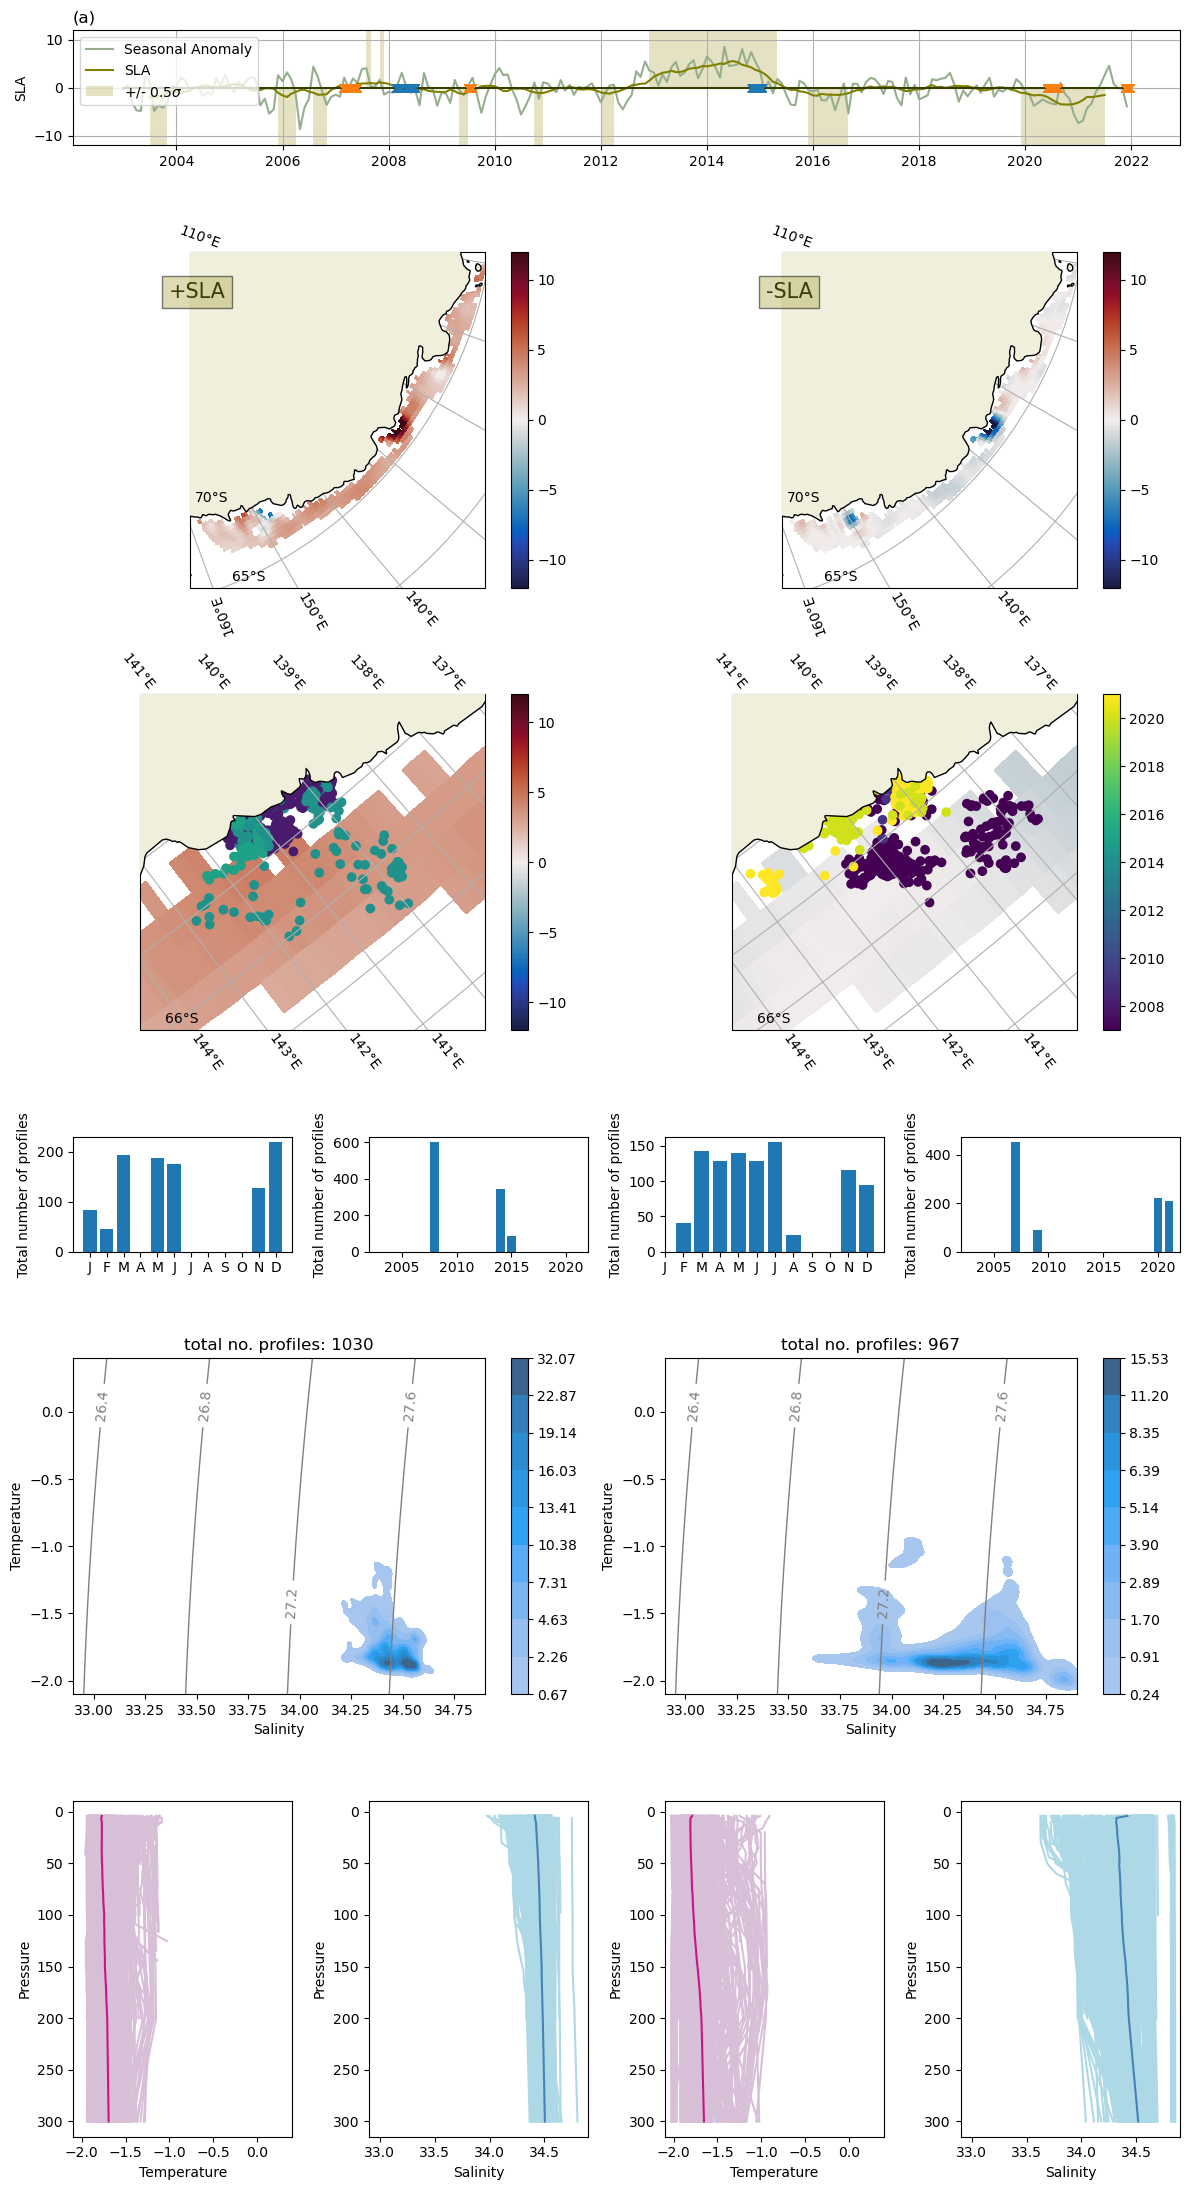

In [17]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax2,ax3],sanom(shelf.crop_da(sla)),'SLA',12,extent,label_loc=[130,-80])

# FIG3: SLA closeup
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax4,ax5],sanom(shelf.crop_da(sla)),'SLA',12,extent_mertz,add_profiles=True)

n = 5
cmp.ts_freq_plot([ 
    fig.add_subplot(gs[n,0]),
    fig.add_subplot(gs[n,1]),
    fig.add_subplot(gs[n,2]),
    fig.add_subplot(gs[n,3]),
])

# FIG4: TS DESNITY
n = 6
cmp.ts_density([
    fig.add_subplot(gs[n:n+2,0:2]),
    fig.add_subplot(gs[n:n+2,2:4])
    ])

# FIG5: TS PROFILES
n = 8
ax8 = fig.add_subplot(gs[8:10,0])
ax9 = fig.add_subplot(gs[8:10,1])
ax10 = fig.add_subplot(gs[8:10,2])
ax11 = fig.add_subplot(gs[8:10,3])
cmp.ts_profiles([ax8,ax9,ax10,ax11])

plt.tight_layout()



In [18]:
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()

In [22]:
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

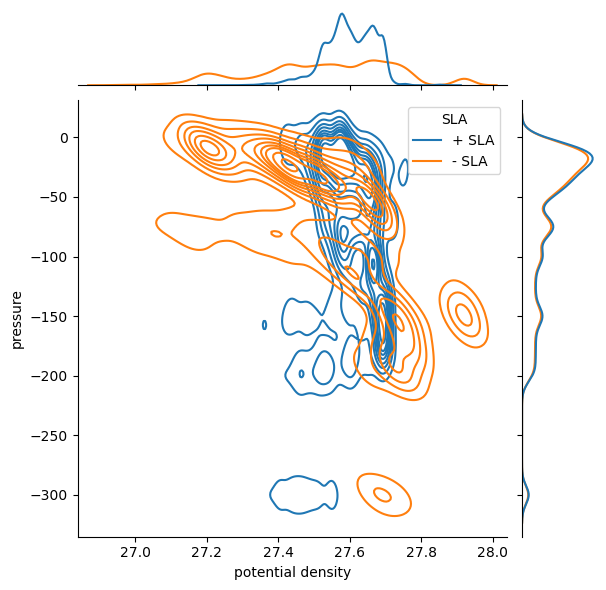

In [23]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)

In [24]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims,lag=2)

reindexing temps..
reindexing psals...
merging...
reindexing temps..
reindexing psals...
merging...


In [26]:
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()
ssn_pos = [get_season(t) for t in tm_pos]
ssn_neg = [get_season(t) for t in tm_neg]

In [27]:
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

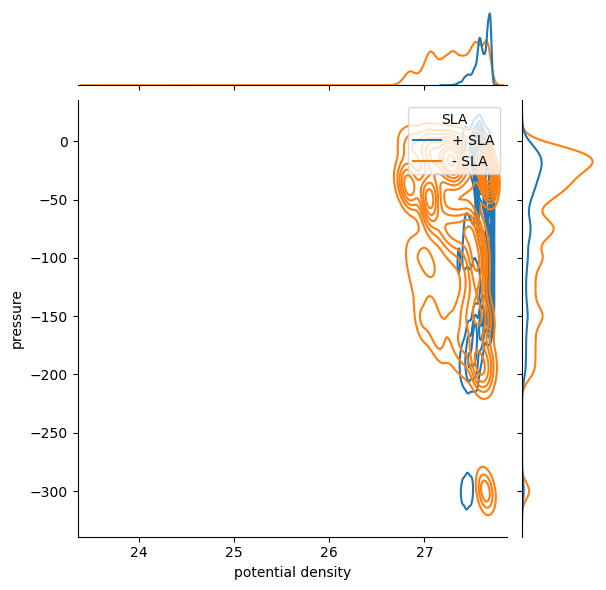

In [28]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)

In [29]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims,lag=3)
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()
ssn_pos = [get_season(t) for t in tm_pos]
ssn_neg = [get_season(t) for t in tm_neg]
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

reindexing temps..
reindexing psals...
merging...
reindexing temps..
reindexing psals...
merging...


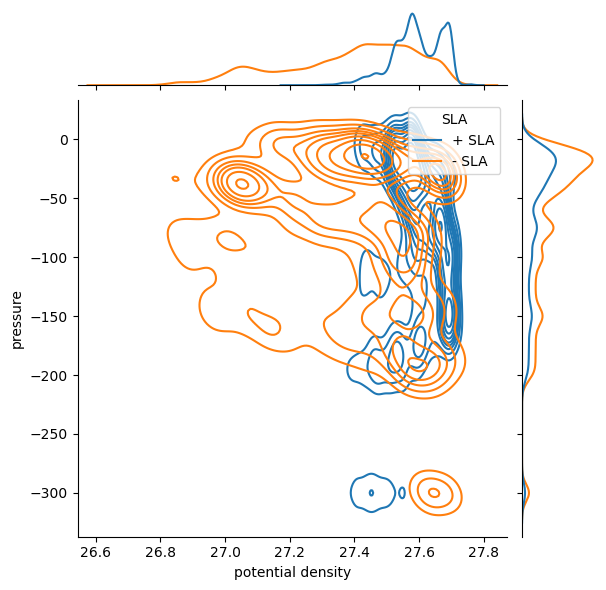

In [30]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)